In [110]:
# Load packages
suppressPackageStartupMessages({
    library(Seurat)
    library(scran)
    library(scater)
    library(batchelor)
    library(SingleCellExperiment)
    library(scater)
    library(Matrix)
    library(reshape2)
    library(data.table)
    library(BiocParallel)
    library(dplyr)
    library(gridExtra)
})

    ncores = 4
    mcparam = MulticoreParam(workers = ncores)
    register(mcparam)
    BPPARAM = SerialParam()

options(repr.plot.width=15, repr.plot.height=8)

In [111]:
main = "/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/"
out_dir = paste0(main, '07_atlas_mapping/')
plot_dir = paste0(main, '07_atlas_mapping/plots/')
dir.create(out_dir, showWarnings = FALSE)
dir.create(plot_dir, showWarnings = FALSE)

source(paste0(main, "mapping_functions_extended.R"))

In [112]:
load_data(normalise=TRUE)
sce_query = sce[Matrix::rowSums(counts(sce)) > 0,]
meta_query = meta

In [113]:
meta_query = meta_query[meta_query$cell %in% sample(meta_query$cell, 5000),]
sce_query = sce_query[,meta_query$cell]

In [114]:
load_extended_atlas_data(normalise=TRUE)
sce_atlas = sce[Matrix::rowSums(counts(sce)) > 0,]
meta_atlas = meta

In [115]:
rm(sce)
rm(meta)

meta_atlas = meta_atlas[meta_atlas$cell %in% sample(meta_atlas$cell, 30000),]
sce_atlas = sce_atlas[,meta_atlas$cell]

In [116]:
sce_atlas = logNormCounts(sce_atlas)

In [117]:
atlas_sce = sce_atlas
atlas_meta = meta_atlas

In [118]:
# genes shared across datasets
shared_genes = merge(data.frame('V1'=names(sce_atlas)), data.frame('V1'=names(sce_query)), by='V1')

# filter cells & genes chimera dataset
sce_query = sce_query[shared_genes$V1,!c(meta_query$doublet | meta_query$stripped)]
meta_query = meta_query[!c(meta_query$doublet | meta_query$stripped),]

# filter cells & genes atlas dataset
sce_atlas = sce_atlas[shared_genes$V1,]
#meta_atlas = meta_atlas[!c(meta_atlas$doublet | meta_atlas$stripped),]

In [119]:
# mappings = lapply(unique(meta_query$sample), function(x){
#     mapWrap(
#         atlas_sce = sce_atlas, 
#         atlas_meta = meta_atlas,
#         map_sce = sce_query[, meta_query$sample == x], 
#         map_meta = meta_query[meta_query$sample == x,], 
#         # genes = marker_genes, 
#         npcs = 5, 
#         k = 30)$mapping
# })
                  
# mappings = do.call(rbind, mappings)

In [121]:
mappings =  mapWrap(
        atlas_sce = sce_atlas, 
        atlas_meta = meta_atlas,
        map_sce = sce_query, 
        map_meta = meta_query, 
        # genes = marker_genes, 
        npcs = 5, 
        k = 30)$mapping

Normalizing joint dataset...

Done


Genes not provided. Computing highly variable genes...

Done


Performing PCA...

Done


Batch effect correction for the atlas...

Done


MNN mapping...

Done


Computing mapping scores...

Done


Writing output...

Done




In [122]:
head(mappings)

,cell,celltype.mapped,celltype_original.mapped,stage.mapped,closest.cell,celltype.score,celltype_original.score,cellstage.score
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
cell_27342,cell_27342,Mesenchyme,Mesenchyme,E8.5,cell_69675,1.0000000,1.0000000,0.5000000
cell_27359,cell_27359,Pharyngeal endoderm,Rostral neurectoderm,E9.0,ext_cell_30927,0.2000000,0.3000000,0.3666667
cell_27369,cell_27369,Embryo proper mesothelium,Surface ectoderm,E9.0,ext_cell_94106,0.2000000,0.3000000,0.5000000
cell_27396,cell_27396,Node,Notochord,E8.0,cell_114616,0.3000000,0.3000000,0.4666667
cell_27400,cell_27400,Surface ectoderm,Surface ectoderm,E9.5,ext_cell_325941,0.2333333,0.4333333,0.4333333
cell_27402,cell_27402,Midgut,Gut,E9.5,ext_cell_316940,0.3000000,0.2666667,0.7333333


In [123]:
meta_complete = merge(meta_query, mappings, by='cell')

In [125]:
meta_complete$umap_1 = as.numeric(meta_complete$umap_1)
meta_complete$umap_2 = as.numeric(meta_complete$umap_2)

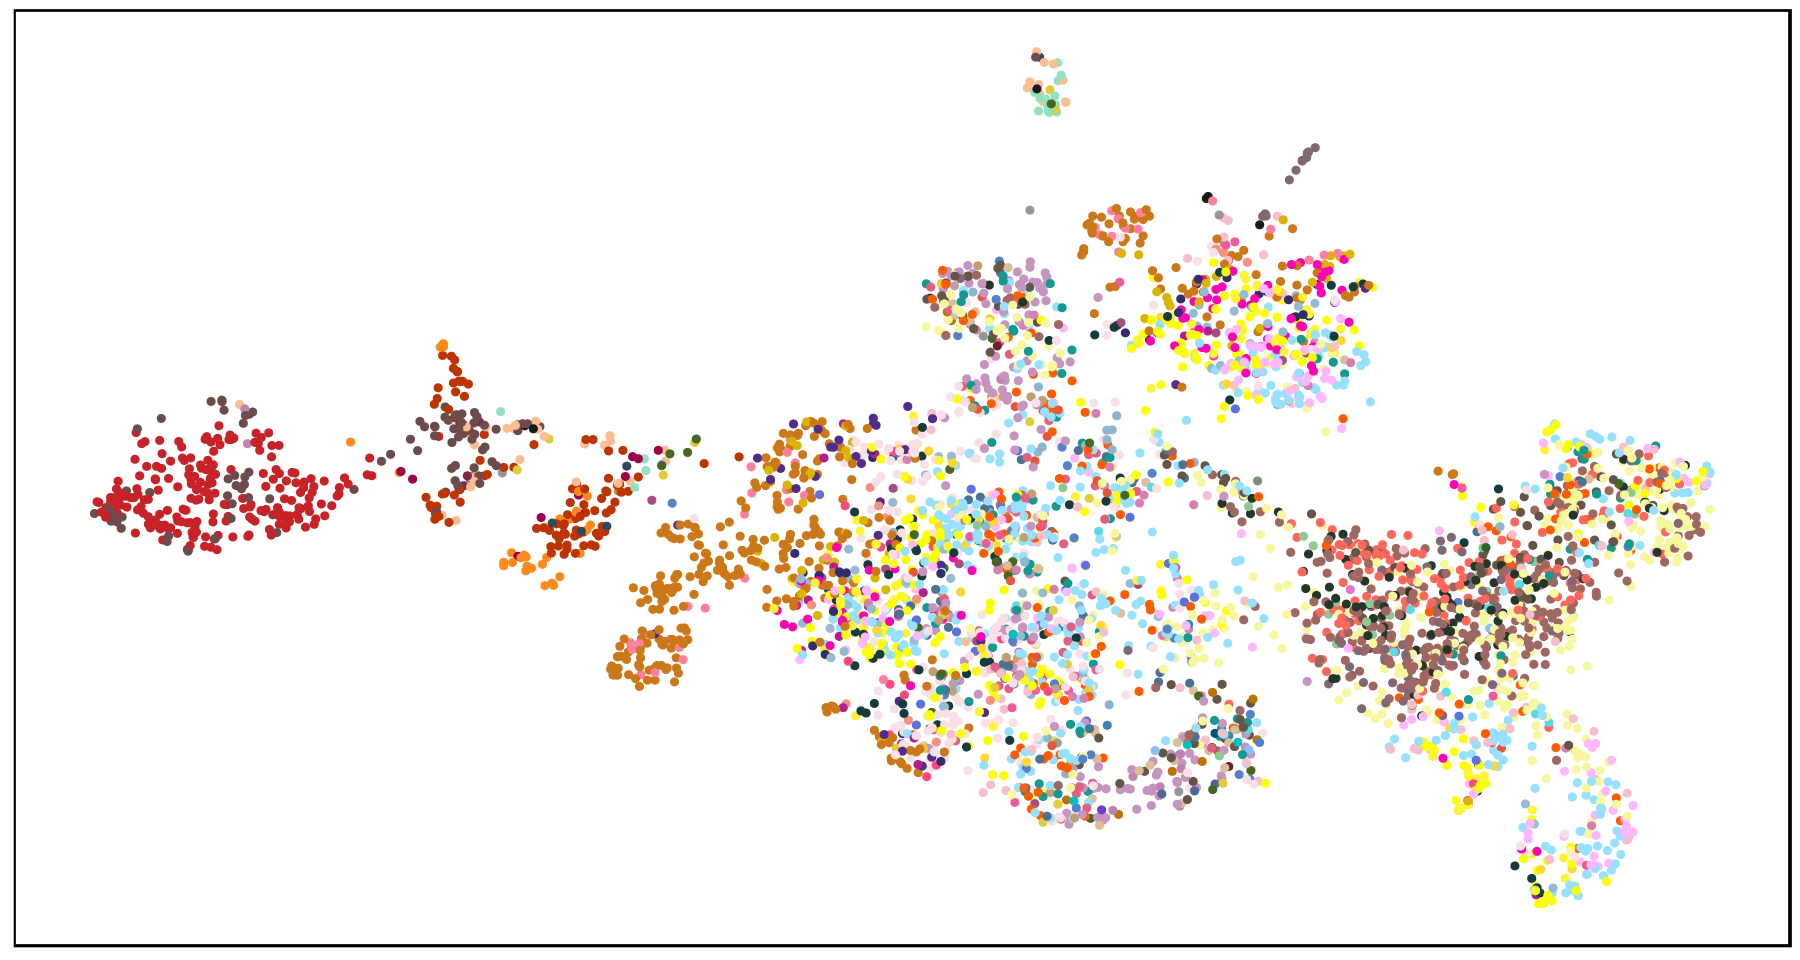

In [128]:
ggplot(meta_complete, aes(umap_1, umap_2, col=celltype.mapped)) + 
    geom_point() +
    scale_colour_manual(values = celltype_colours_final, name = "celltype") +
    umap_theme


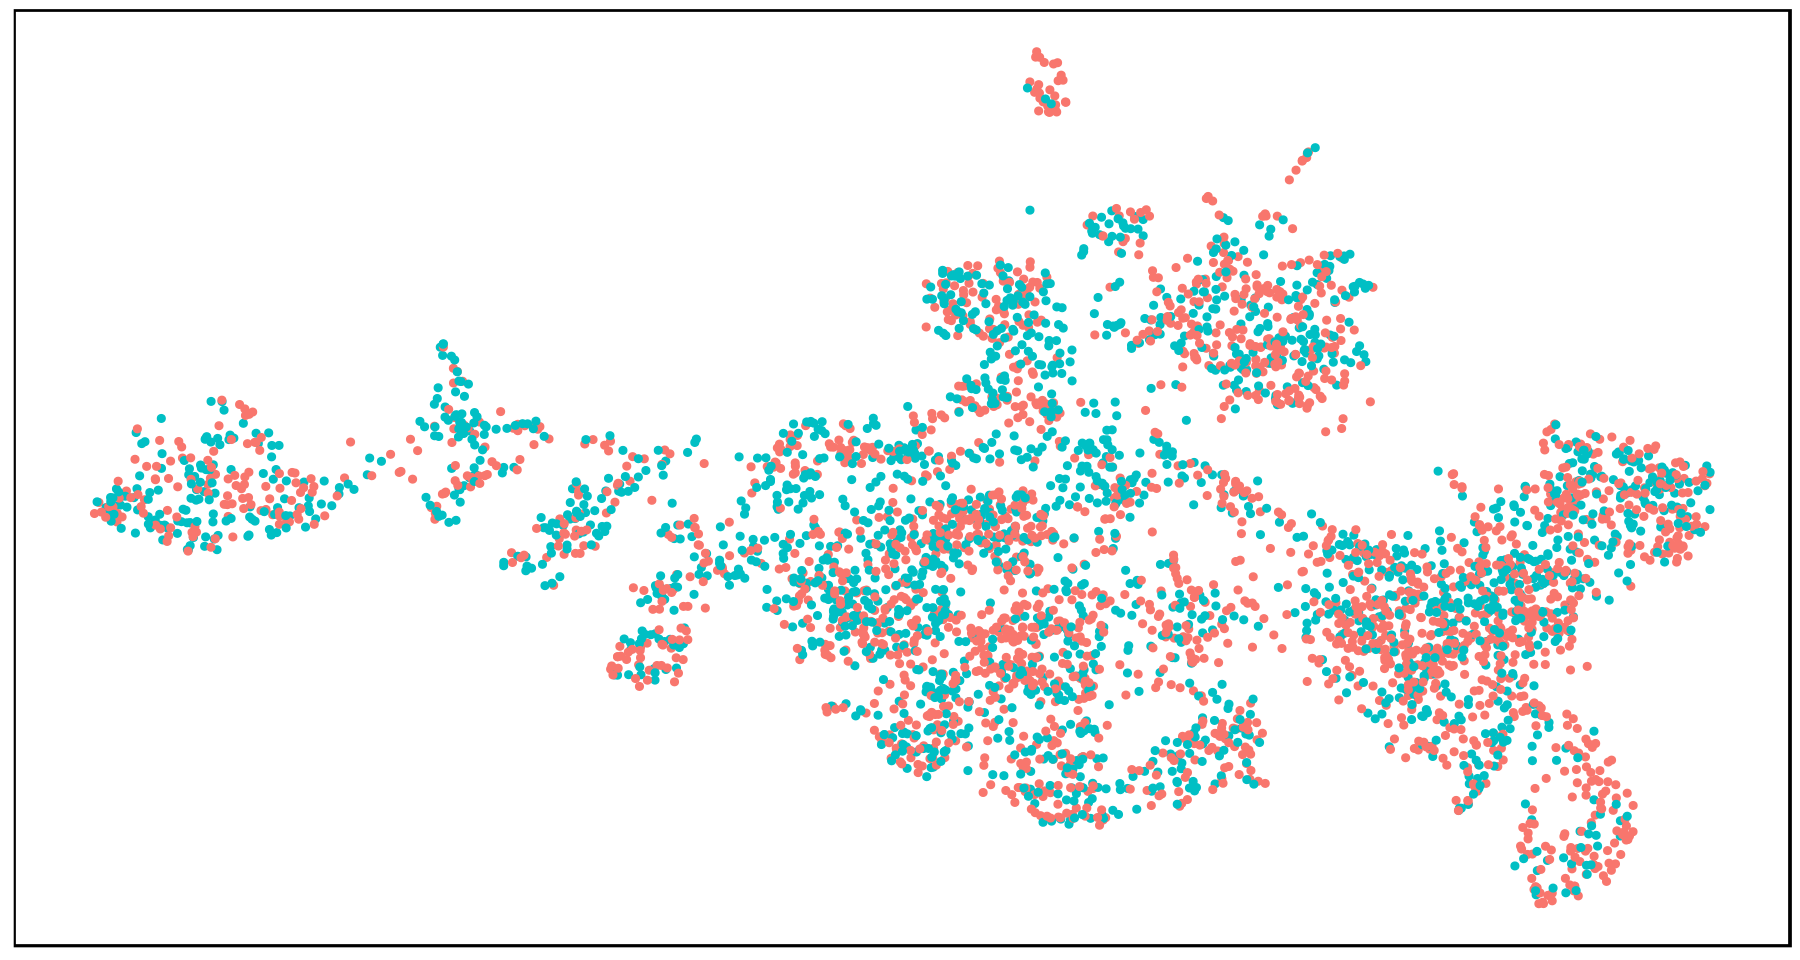

In [127]:
ggplot(meta_complete, aes(umap_1, umap_2, col=as.factor(tdTom))) + 
    geom_point() +
 #   scale_colour_manual(values = celltype_colours_final, name = "celltype") +
    umap_theme